In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [14]:
# Load dataset

df = pd.read_csv("../data/Students.csv")

print("Dataset loaded successfully")
df.head()

Dataset loaded successfully


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [15]:
# Dataset basic information

print("Shape of dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

Shape of dataset: (1000, 8)

Column Names:
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None

Missing Values:


In [16]:
# Check duplicate values

print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates if any
df.drop_duplicates(inplace=True)

print("Duplicates removed successfully")

Duplicate rows: 0
Duplicates removed successfully


In [17]:
# Create total marks column

df["total_marks"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
)

print("Total marks column created successfully")

df.head()

Total marks column created successfully


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_marks
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [18]:
# Create grade column

def grade(total):
    if total >= 250:
        return "A"
    elif total >= 200:
        return "B"
    elif total >= 150:
        return "C"
    else:
        return "D"

df["grade"] = df["total_marks"].apply(grade)

print("Grade column created successfully")

df.head()

Grade column created successfully


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_marks,grade
0,female,group B,bachelor's degree,standard,none,72,72,74,218,B
1,female,group C,some college,standard,completed,69,90,88,247,B
2,female,group B,master's degree,standard,none,90,95,93,278,A
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,D
4,male,group C,some college,standard,none,76,78,75,229,B


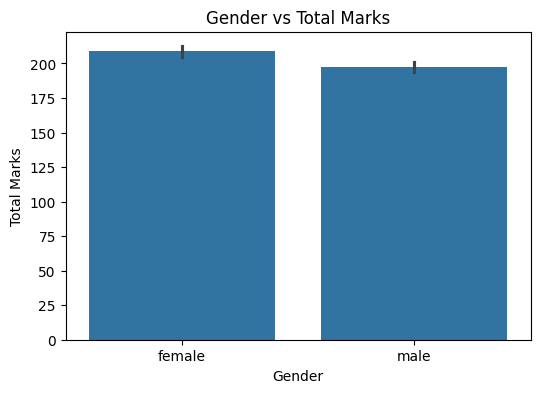

In [19]:
plt.figure(figsize=(6,4))
sns.barplot(x="gender", y="total_marks", data=df)

plt.title("Gender vs Total Marks")
plt.xlabel("Gender")
plt.ylabel("Total Marks")

plt.show()

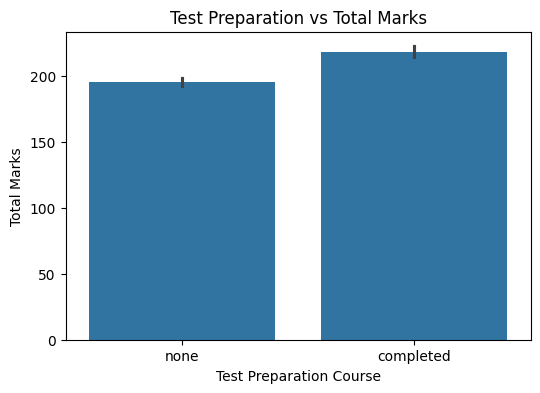

In [20]:
plt.figure(figsize=(6,4))
sns.barplot(x="test preparation course", y="total_marks", data=df)

plt.title("Test Preparation vs Total Marks")
plt.xlabel("Test Preparation Course")
plt.ylabel("Total Marks")

plt.show()

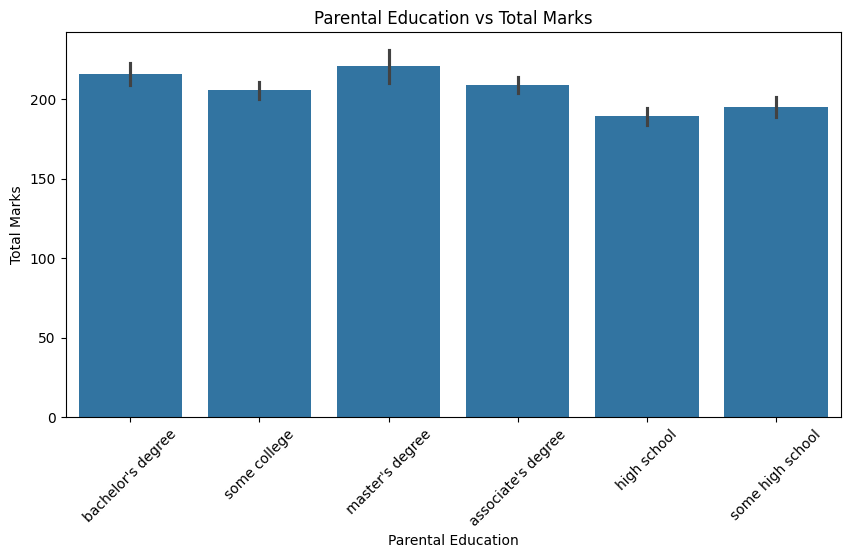

In [21]:
plt.figure(figsize=(10,5))
sns.barplot(
    x="parental level of education",
    y="total_marks",
    data=df
)

plt.xticks(rotation=45)
plt.title("Parental Education vs Total Marks")
plt.xlabel("Parental Education")
plt.ylabel("Total Marks")

plt.show()

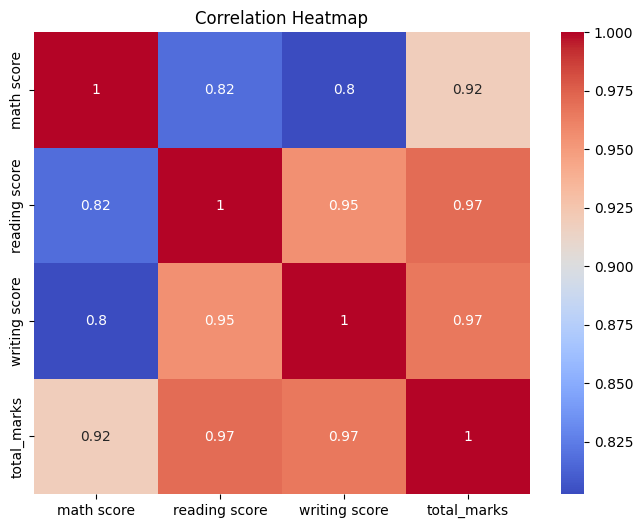

In [22]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

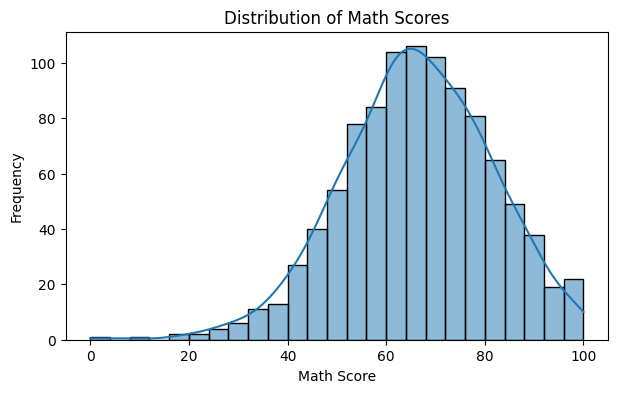

In [23]:
plt.figure(figsize=(7,4))

sns.histplot(df["math score"], kde=True)

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")

plt.show()

In [24]:
# Select features and target

X = df[["reading score", "writing score"]]
y = df["math score"]

print("Features and target selected successfully")

Features and target selected successfully


In [25]:
# Split data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data split successfully")
print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Data split successfully
Training data size: (800, 2)
Testing data size: (200, 2)


In [26]:
# Train Linear Regression Model

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [27]:
# Make predictions

predictions = model.predict(X_test)

print("Predictions completed")
print(predictions[:10])

Predictions completed
[80.18552589 65.6849504  69.44210877 72.01611012 76.82827724 72.22379745
 65.26957575 59.81777453 69.44210877 50.08186415]


In [28]:
# Model evaluation

from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error (MAE):", mae)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 7.35130878253051
R2 Score: 0.6825697127424625


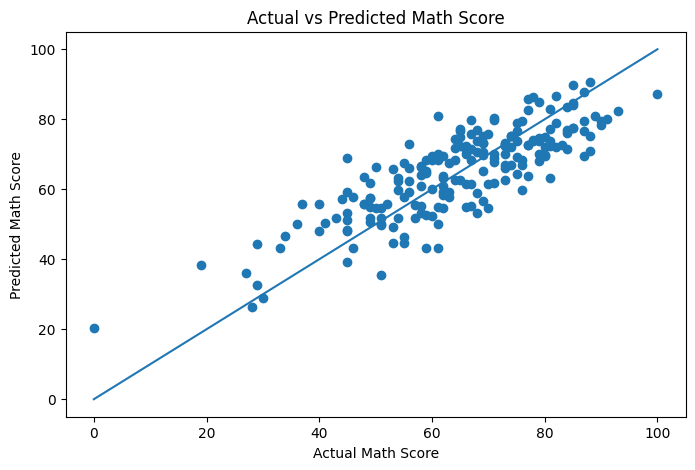

In [29]:
# Actual vs Predicted Graph with ideal line

plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.title("Actual vs Predicted Math Score")

plt.show()